In [1]:
# Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU available: {gpu_name}")
    print(f"   Memory: {gpu_mem:.1f} GB")
else:
    device = torch.device('cpu')
    print("No GPU detected. This notebook works on CPU too.")
    print("   Go to Runtime -> Change runtime type -> GPU")

print(f"\nPython {sys.version.split()[0]}")
print(f"PyTorch {torch.__version__}")

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

%matplotlib inline

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


GPU available: NVIDIA H100 80GB HBM3
   Memory: 85.3 GB

Python 3.12.10
PyTorch 2.7.0+cu128
Random seed set to 42


# Memory Anatomy: Weights, Gradients, and Optimizer States -- Vizuara

## 1. Why Does This Matter?

When you try to train a 7-billion-parameter model on a 24 GB GPU, you hit an OOM error even though the weights are "only" 14 GB. Where did the rest of the memory go?

In this notebook, we will calculate the exact memory footprint of each component: **weights**, **gradients**, and **optimizer states**. By the end, you will be able to predict the memory cost of training any model before you even load it onto a GPU.

**What you will build:** A memory calculator that breaks down training memory into its four components for any model configuration.

## 2. Building Intuition

Think of training a neural network like running a business.

- **Weights** are like your inventory -- the core asset you are optimizing.
- **Gradients** are like your daily sales reports -- they tell you which direction to adjust.
- **Optimizer states** are like your accountant's records -- they track momentum ("are sales trending up?") and variance ("how volatile are sales?") to make smarter adjustments.

Just as an accountant's records can be far larger than the inventory list itself, the optimizer states are often **the largest** memory consumer during training.

Let us make this concrete with numbers.

## 3. The Mathematics

For a model with $P$ parameters trained using mixed precision with Adam:

| Component | Formula | Bytes per Param |
|-----------|---------|----------------|
| Weights (fp16) | $2P$ | 2 |
| Gradients (fp16) | $2P$ | 2 |
| fp32 Master Weights | $4P$ | 4 |
| Adam First Moment $m$ (fp32) | $4P$ | 4 |
| Adam Second Moment $v$ (fp32) | $4P$ | 4 |
| **Total** | **$16P$** | **16** |

So 16 bytes per parameter -- **8x** the memory of just the fp16 weights.

For a 7B model: $7 \times 10^9 \times 16 = 112$ GB (before activations).

In [2]:
# Let us compute this step by step

def bytes_to_gb(num_bytes):
    """Convert bytes to gigabytes."""
    return num_bytes / (1024**3)

def weight_memory_gb(num_params, bytes_per_param=2):
    """Calculate weight memory in GB.

    Args:
        num_params: Number of model parameters (e.g., 7e9 for 7B)
        bytes_per_param: 4 for fp32, 2 for fp16/bf16
    """
    return bytes_to_gb(num_params * bytes_per_param)

# Compute weight memory for several well-known models
models = {
    "GPT-2 (124M)": 124e6,
    "GPT-2 XL (1.5B)": 1.5e9,
    "LLaMA-7B": 7e9,
    "LLaMA-13B": 13e9,
    "LLaMA-70B": 70e9,
}

print(f"{'Model':<20} {'fp32 (4B)':<15} {'fp16/bf16 (2B)':<15}")
print("-" * 50)
for name, params in models.items():
    fp32 = weight_memory_gb(params, 4)
    fp16 = weight_memory_gb(params, 2)
    print(f"{name:<20} {fp32:>10.2f} GB   {fp16:>10.2f} GB")

Model                fp32 (4B)       fp16/bf16 (2B) 
--------------------------------------------------
GPT-2 (124M)               0.46 GB         0.23 GB
GPT-2 XL (1.5B)            5.59 GB         2.79 GB
LLaMA-7B                  26.08 GB        13.04 GB
LLaMA-13B                 48.43 GB        24.21 GB
LLaMA-70B                260.77 GB       130.39 GB


### Floating-Point Formats

Let us verify the actual memory of different dtypes in PyTorch.

In [3]:
# Verify floating-point sizes with PyTorch
dtypes = {
    "float32 (fp32)": torch.float32,
    "float16 (fp16)": torch.float16,
    "bfloat16 (bf16)": torch.bfloat16,
}

print("Floating-Point Format Verification")
print("=" * 50)

for name, dtype in dtypes.items():
    t = torch.tensor([1.0], dtype=dtype)
    bytes_per_elem = t.element_size()
    print(f"{name}: {bytes_per_elem} bytes per element")

print("\n--- Precision comparison ---")
val = 1.0000001  # A value that needs precision
for name, dtype in dtypes.items():
    t = torch.tensor([val], dtype=dtype)
    print(f"{name}: {val} -> {t.item():.10f}")

print("\n--- Range comparison ---")
for name, dtype in dtypes.items():
    info = torch.finfo(dtype)
    print(f"{name}: max = {info.max:.2e}, min (positive) = {info.tiny:.2e}")

Floating-Point Format Verification
float32 (fp32): 4 bytes per element
float16 (fp16): 2 bytes per element
bfloat16 (bf16): 2 bytes per element

--- Precision comparison ---
float32 (fp32): 1.0000001 -> 1.0000001192
float16 (fp16): 1.0000001 -> 1.0000000000
bfloat16 (bf16): 1.0000001 -> 1.0000000000

--- Range comparison ---
float32 (fp32): max = 3.40e+38, min (positive) = 1.18e-38
float16 (fp16): max = 6.55e+04, min (positive) = 6.10e-05
bfloat16 (bf16): max = 3.39e+38, min (positive) = 1.18e-38


Notice that bf16 has the same range as fp32 (same 8-bit exponent) but less precision. For deep learning, range matters more than precision, which is why bf16 is preferred over fp16 on hardware that supports it.

## 4. Let's Build It -- Component by Component

### Component 1: Model Weights

Let us create a real model and measure its weight memory.

In [4]:
import torch.nn as nn

class SimplifiedTransformerBlock(nn.Module):
    """A simplified transformer block to demonstrate memory."""
    def __init__(self, hidden_dim=768, num_heads=12, ffn_mult=4):
        super().__init__()
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * ffn_mult),
            nn.GELU(),
            nn.Linear(hidden_dim * ffn_mult, hidden_dim),
        )

    def forward(self, x):
        h = self.ln1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        x = x + self.ffn(self.ln2(x))
        return x

class TinyTransformer(nn.Module):
    """A minimal transformer for memory experiments."""
    def __init__(self, vocab_size=32000, hidden_dim=768, num_layers=12, num_heads=12):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim)
        self.layers = nn.ModuleList([
            SimplifiedTransformerBlock(hidden_dim, num_heads)
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, vocab_size, bias=False)

    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers:
            x = layer(x)
        x = self.ln_f(x)
        return self.head(x)

# Create model (GPT-2 scale: ~124M params)
model = TinyTransformer(
    vocab_size=32000,
    hidden_dim=768,
    num_layers=12,
    num_heads=12
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nWeight memory (fp32): {weight_memory_gb(total_params, 4):.2f} GB")
print(f"Weight memory (fp16): {weight_memory_gb(total_params, 2):.2f} GB")

Total parameters: 134,208,000 (134.2M)
Trainable parameters: 134,208,000

Weight memory (fp32): 0.50 GB
Weight memory (fp16): 0.25 GB


In [5]:
# Measure actual memory of the model in different dtypes

def measure_model_memory(model, dtype=torch.float32):
    """Measure the actual memory consumed by model parameters."""
    total_bytes = 0
    for p in model.parameters():
        total_bytes += p.numel() * p.element_size()
    return total_bytes

# fp32 model
model_fp32 = TinyTransformer().to(torch.float32)
mem_fp32 = measure_model_memory(model_fp32)

# fp16 model
model_fp16 = TinyTransformer().to(torch.float16)
mem_fp16 = measure_model_memory(model_fp16)

# bf16 model
model_bf16 = TinyTransformer().to(torch.bfloat16)
mem_bf16 = measure_model_memory(model_bf16)

print("Actual measured model memory:")
print(f"  fp32: {bytes_to_gb(mem_fp32):.4f} GB ({mem_fp32/1e6:.1f} MB)")
print(f"  fp16: {bytes_to_gb(mem_fp16):.4f} GB ({mem_fp16/1e6:.1f} MB)")
print(f"  bf16: {bytes_to_gb(mem_bf16):.4f} GB ({mem_bf16/1e6:.1f} MB)")
print(f"\nfp32 / fp16 ratio: {mem_fp32 / mem_fp16:.1f}x (expected: 2.0x)")

# Clean up to save memory
del model_fp32, model_fp16, model_bf16

Actual measured model memory:
  fp32: 0.5000 GB (536.8 MB)
  fp16: 0.2500 GB (268.4 MB)
  bf16: 0.2500 GB (268.4 MB)

fp32 / fp16 ratio: 2.0x (expected: 2.0x)


### Component 2: Gradients

During backpropagation, PyTorch stores a gradient for every trainable parameter. The gradient has **exactly the same shape** as the weight.

In [6]:
# Demonstrate that gradients have the same shape as weights

model = TinyTransformer().to(device)

# Create a dummy input and do a forward + backward pass
dummy_input = torch.randint(0, 32000, (2, 64)).to(device)  # batch=2, seq=64
output = model(dummy_input)
loss = output.sum()  # dummy loss
loss.backward()

# Check that every parameter has a gradient with the same shape
print(f"{'Parameter':<50} {'Weight Shape':<20} {'Grad Shape':<20} {'Match'}")
print("-" * 100)

total_grad_bytes = 0
for name, param in model.named_parameters():
    if param.grad is not None:
        match = param.shape == param.grad.shape
        total_grad_bytes += param.grad.numel() * param.grad.element_size()
        # Only show a few representative layers
        if 'layers.0' in name or 'embed' in name or 'head' in name:
            print(f"{name:<50} {str(list(param.shape)):<20} {str(list(param.grad.shape)):<20} {match}")

print(f"\nTotal gradient memory: {bytes_to_gb(total_grad_bytes):.4f} GB")
print(f"Total weight memory:   {bytes_to_gb(measure_model_memory(model)):.4f} GB")
print(f"Ratio: {total_grad_bytes / measure_model_memory(model):.1f}x (gradients == weights in fp32)")

Parameter                                          Weight Shape         Grad Shape           Match
----------------------------------------------------------------------------------------------------
embed.weight                                       [32000, 768]         [32000, 768]         True
layers.0.ln1.weight                                [768]                [768]                True
layers.0.ln1.bias                                  [768]                [768]                True
layers.0.attn.in_proj_weight                       [2304, 768]          [2304, 768]          True
layers.0.attn.in_proj_bias                         [2304]               [2304]               True
layers.0.attn.out_proj.weight                      [768, 768]           [768, 768]           True
layers.0.attn.out_proj.bias                        [768]                [768]                True
layers.0.ln2.weight                                [768]                [768]                True
layers.0.ln2.bia

### Component 3: Optimizer States (Adam)

Adam stores two additional tensors per parameter:
- **First moment** $m$: exponential moving average of gradients (momentum)
- **Second moment** $v$: exponential moving average of squared gradients

Both are always in fp32, even when the model is in fp16.

In [7]:
# Create an Adam optimizer and inspect its state

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# The optimizer state is empty until the first step
print("Before first step:")
print(f"  Optimizer state entries: {len(optimizer.state)}")

# Do one optimization step
optimizer.step()

print(f"\nAfter first step:")
print(f"  Optimizer state entries: {len(optimizer.state)}")

# Inspect the optimizer state for one parameter
first_param = list(model.parameters())[0]
state = optimizer.state[first_param]

print(f"\nOptimizer state keys: {list(state.keys())}")
print(f"\n  step: {state['step']}")
print(f"  exp_avg (m) shape: {state['exp_avg'].shape}, dtype: {state['exp_avg'].dtype}")
print(f"  exp_avg_sq (v) shape: {state['exp_avg_sq'].shape}, dtype: {state['exp_avg_sq'].dtype}")
print(f"  Weight shape: {first_param.shape}, dtype: {first_param.dtype}")
print(f"\n  m and v have SAME shape as weight: {state['exp_avg'].shape == first_param.shape}")
print(f"  m and v are fp32: {state['exp_avg'].dtype == torch.float32}")

Before first step:
  Optimizer state entries: 0

After first step:
  Optimizer state entries: 148

Optimizer state keys: ['step', 'exp_avg', 'exp_avg_sq']

  step: 1.0
  exp_avg (m) shape: torch.Size([32000, 768]), dtype: torch.float32
  exp_avg_sq (v) shape: torch.Size([32000, 768]), dtype: torch.float32
  Weight shape: torch.Size([32000, 768]), dtype: torch.float32

  m and v have SAME shape as weight: True
  m and v are fp32: True


In [8]:
# Compute total optimizer state memory

total_opt_bytes = 0
num_state_tensors = 0

for param in model.parameters():
    if param in optimizer.state:
        state = optimizer.state[param]
        for key in ['exp_avg', 'exp_avg_sq']:
            if key in state:
                tensor = state[key]
                total_opt_bytes += tensor.numel() * tensor.element_size()
                num_state_tensors += 1

total_weight_bytes = measure_model_memory(model)

print("Optimizer State Memory Breakdown")
print("=" * 50)
print(f"Number of state tensors: {num_state_tensors}")
print(f"  (2 per parameter: m and v)")
print(f"\nOptimizer state memory: {bytes_to_gb(total_opt_bytes):.4f} GB")
print(f"Model weight memory:    {bytes_to_gb(total_weight_bytes):.4f} GB")
print(f"Ratio: {total_opt_bytes / total_weight_bytes:.1f}x")
print(f"\nThe optimizer states are {total_opt_bytes / total_weight_bytes:.1f}x the weight memory!")
print(f"This is because m and v are fp32 (4 bytes each) while weights are also fp32 here.")

Optimizer State Memory Breakdown
Number of state tensors: 296
  (2 per parameter: m and v)

Optimizer state memory: 0.9999 GB
Model weight memory:    0.5000 GB
Ratio: 2.0x

The optimizer states are 2.0x the weight memory!
This is because m and v are fp32 (4 bytes each) while weights are also fp32 here.


### Putting It Together: The Full Memory Breakdown

Let us build a comprehensive memory calculator.

In [9]:
def training_memory_breakdown(num_params, precision="mixed"):
    """Calculate the memory breakdown for training with Adam.

    Args:
        num_params: Number of parameters (e.g., 7e9)
        precision: 'fp32', 'fp16', or 'mixed'

    Returns:
        Dictionary with memory for each component in GB.
    """
    if precision == "fp32":
        weight_bytes = num_params * 4
        grad_bytes = num_params * 4
        # Adam m + v in fp32
        opt_bytes = num_params * 4 * 2  # m + v
    elif precision == "fp16":
        weight_bytes = num_params * 2
        grad_bytes = num_params * 2
        # Adam m + v still in fp32 for stability
        opt_bytes = num_params * 4 * 2  # m + v
    elif precision == "mixed":
        weight_bytes = num_params * 2  # fp16 working weights
        grad_bytes = num_params * 2    # fp16 gradients
        # fp32 master copy + m + v
        opt_bytes = num_params * 4 * 3  # master + m + v
    else:
        raise ValueError(f"Unknown precision: {precision}")

    return {
        "weights": bytes_to_gb(weight_bytes),
        "gradients": bytes_to_gb(grad_bytes),
        "optimizer": bytes_to_gb(opt_bytes),
        "total": bytes_to_gb(weight_bytes + grad_bytes + opt_bytes),
    }

# Compare models at different scales
models_to_check = {
    "GPT-2 (124M)": 124e6,
    "LLaMA-7B": 7e9,
    "LLaMA-13B": 13e9,
    "LLaMA-70B": 70e9,
}

print("Memory Breakdown (Mixed Precision + Adam, EXCLUDING activations)")
print("=" * 80)
print(f"{'Model':<20} {'Weights':<12} {'Gradients':<12} {'Optimizer':<12} {'Total':<12}")
print("-" * 80)

for name, params in models_to_check.items():
    mem = training_memory_breakdown(params, "mixed")
    print(f"{name:<20} {mem['weights']:>8.2f} GB  {mem['gradients']:>8.2f} GB  {mem['optimizer']:>8.2f} GB  {mem['total']:>8.2f} GB")

Memory Breakdown (Mixed Precision + Adam, EXCLUDING activations)
Model                Weights      Gradients    Optimizer    Total       
--------------------------------------------------------------------------------
GPT-2 (124M)             0.23 GB      0.23 GB      1.39 GB      1.85 GB
LLaMA-7B                13.04 GB     13.04 GB     78.23 GB    104.31 GB
LLaMA-13B               24.21 GB     24.21 GB    145.29 GB    193.72 GB
LLaMA-70B              130.39 GB    130.39 GB    782.31 GB   1043.08 GB


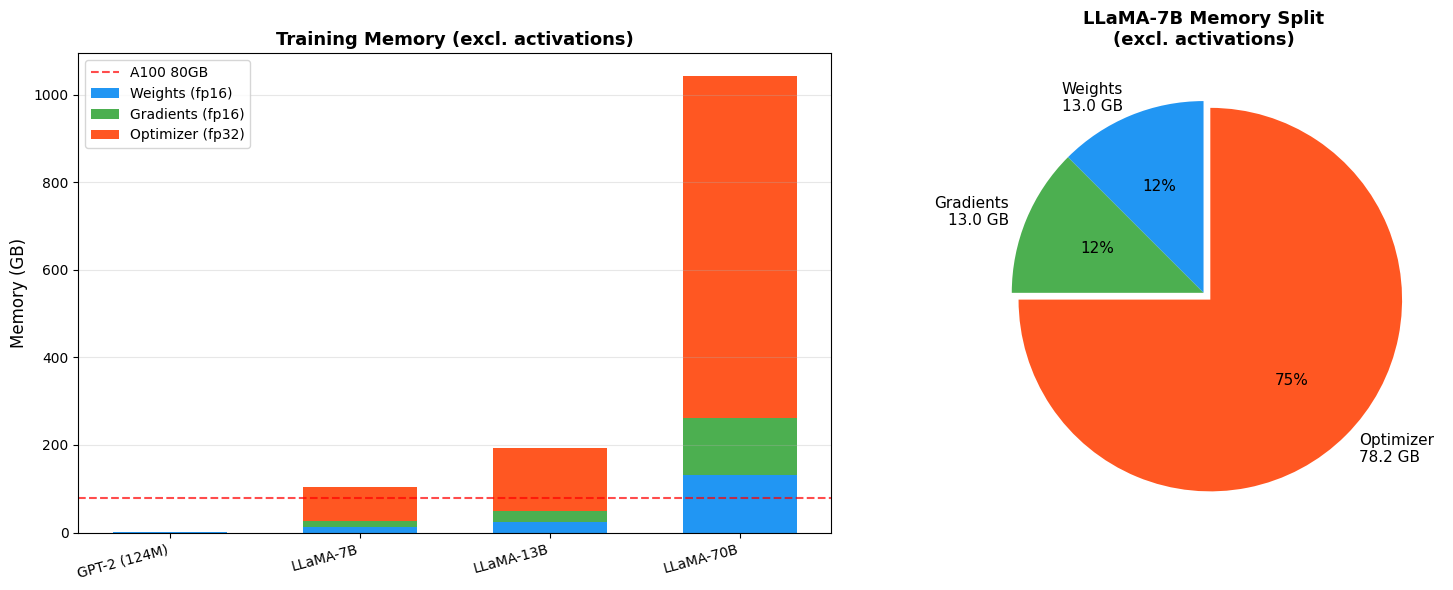


Key insight: Optimizer states consume 75% of non-activation memory.
This is why ZeRO optimizer partitioning is so impactful.


In [10]:
# Visualize the memory breakdown

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Stacked bar chart for different models ---
model_names = list(models_to_check.keys())
weights_vals = []
grad_vals = []
opt_vals = []

for params in models_to_check.values():
    mem = training_memory_breakdown(params, "mixed")
    weights_vals.append(mem['weights'])
    grad_vals.append(mem['gradients'])
    opt_vals.append(mem['optimizer'])

x = np.arange(len(model_names))
width = 0.6

bars1 = axes[0].bar(x, weights_vals, width, label='Weights (fp16)', color='#2196F3')
bars2 = axes[0].bar(x, grad_vals, width, bottom=weights_vals, label='Gradients (fp16)', color='#4CAF50')
bars3 = axes[0].bar(x, opt_vals, width,
                     bottom=[w+g for w,g in zip(weights_vals, grad_vals)],
                     label='Optimizer (fp32)', color='#FF5722')

# Add A100 80GB line
axes[0].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='A100 80GB')

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('Memory (GB)', fontsize=12)
axes[0].set_title('Training Memory (excl. activations)', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# --- Panel 2: Pie chart for LLaMA-7B ---
mem_7b = training_memory_breakdown(7e9, "mixed")
sizes = [mem_7b['weights'], mem_7b['gradients'], mem_7b['optimizer']]
labels_pie = [
    f"Weights\n{mem_7b['weights']:.1f} GB",
    f"Gradients\n{mem_7b['gradients']:.1f} GB",
    f"Optimizer\n{mem_7b['optimizer']:.1f} GB",
]
colors = ['#2196F3', '#4CAF50', '#FF5722']
explode = (0, 0, 0.05)

axes[1].pie(sizes, labels=labels_pie, colors=colors, explode=explode,
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('LLaMA-7B Memory Split\n(excl. activations)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey insight: Optimizer states consume {mem_7b['optimizer']/mem_7b['total']*100:.0f}% of non-activation memory.")
print(f"This is why ZeRO optimizer partitioning is so impactful.")

## 5. Your Turn -- TODO Exercises

### TODO 1: SGD vs Adam Memory

SGD with momentum stores only **one** state tensor per parameter (the momentum buffer), instead of Adam's two (m and v). Write a function that computes the optimizer memory for SGD with momentum, and compare it to Adam for a 7B model.

In [11]:
# TODO: Implement SGD memory calculator and compare to Adam

def sgd_optimizer_memory_gb(num_params):
    """Calculate optimizer state memory for SGD with momentum (fp32).

    SGD with momentum stores ONE state tensor per parameter:
    - momentum buffer (fp32, 4 bytes per param)

    Compare this to Adam which stores TWO:
    - first moment m (fp32, 4 bytes per param)
    - second moment v (fp32, 4 bytes per param)
    """
    # TODO: Return SGD optimizer memory in GB
    # Hint: SGD with momentum has 1 state tensor * 4 bytes per param
    return bytes_to_gb(num_params * 4)  # 4 bytes per param for momentum buffer
    

def adam_optimizer_memory_gb(num_params, include_master=True):
    """Calculate optimizer state memory for Adam (fp32)."""
    # TODO: Return Adam optimizer memory in GB
    # Hint: Adam has 2 state tensors * 4 bytes per param
    # If include_master: add fp32 master weights (4 bytes per param)
    opt_bytes = num_params * 4 * 2  # m + v
    if include_master:
        opt_bytes += num_params * 4  # master weights
    return bytes_to_gb(opt_bytes)
   

# Test with 7B parameters
num_params = 7e9
sgd_mem = sgd_optimizer_memory_gb(num_params)
adam_mem = adam_optimizer_memory_gb(num_params, include_master=True)

print(f"Optimizer memory for 7B model:")
print(f"  SGD + momentum:  {sgd_mem:.2f} GB")
print(f"  Adam (mixed):    {adam_mem:.2f} GB")
print(f"  Adam uses {adam_mem/sgd_mem:.1f}x more memory than SGD")

Optimizer memory for 7B model:
  SGD + momentum:  26.08 GB
  Adam (mixed):    78.23 GB
  Adam uses 3.0x more memory than SGD


### TODO 2: Empirical Verification

Create an Adam optimizer for our TinyTransformer model. After one step, sum up the actual memory of all optimizer state tensors. Compare your measurement to the theoretical formula.

**Hint:** Loop over `optimizer.state.values()` and check for `exp_avg` and `exp_avg_sq` keys.

In [ ]:
# TODO: Empirically measure optimizer state memory

# Step 1: Create model and optimizer
model_test = TinyTransformer().to(device)
optimizer_test = torch.optim.Adam(model_test.parameters(), lr=1e-4)

# Step 2: Do a forward + backward + step to populate optimizer state
dummy = torch.randint(0, 32000, (2, 64)).to(device)
loss = model_test(dummy).sum()
loss.backward()
optimizer_test.step()

# Step 3: TODO - Sum up the memory of all optimizer state tensors
total_opt_measured = 0
for state in optimizer_test.state.values():
    # TODO: For each state dict, sum up the memory of 'exp_avg' and 'exp_avg_sq'
    # Hint: tensor.numel() * tensor.element_size() gives bytes
    pass  # REPLACE THIS

# Step 4: Compare to theoretical
num_params_test = sum(p.numel() for p in model_test.parameters())
theoretical_bytes = num_params_test * 4 * 2  # m + v, both fp32

print(f"Model parameters: {num_params_test:,}")
print(f"Measured optimizer memory: {bytes_to_gb(total_opt_measured):.4f} GB")
print(f"Theoretical optimizer memory: {bytes_to_gb(theoretical_bytes):.4f} GB")
print(f"Match: {abs(total_opt_measured - theoretical_bytes) < 1024}")

del model_test, optimizer_test

### TODO 3: Scaling Law Visualization

Create a line plot showing how total training memory (weights + gradients + optimizer, excluding activations) scales with model size from 100M to 100B parameters. Plot three lines: one for fp32 training, one for fp16 training, and one for mixed precision. Add horizontal lines for common GPU memory sizes (16 GB, 24 GB, 40 GB, 80 GB).

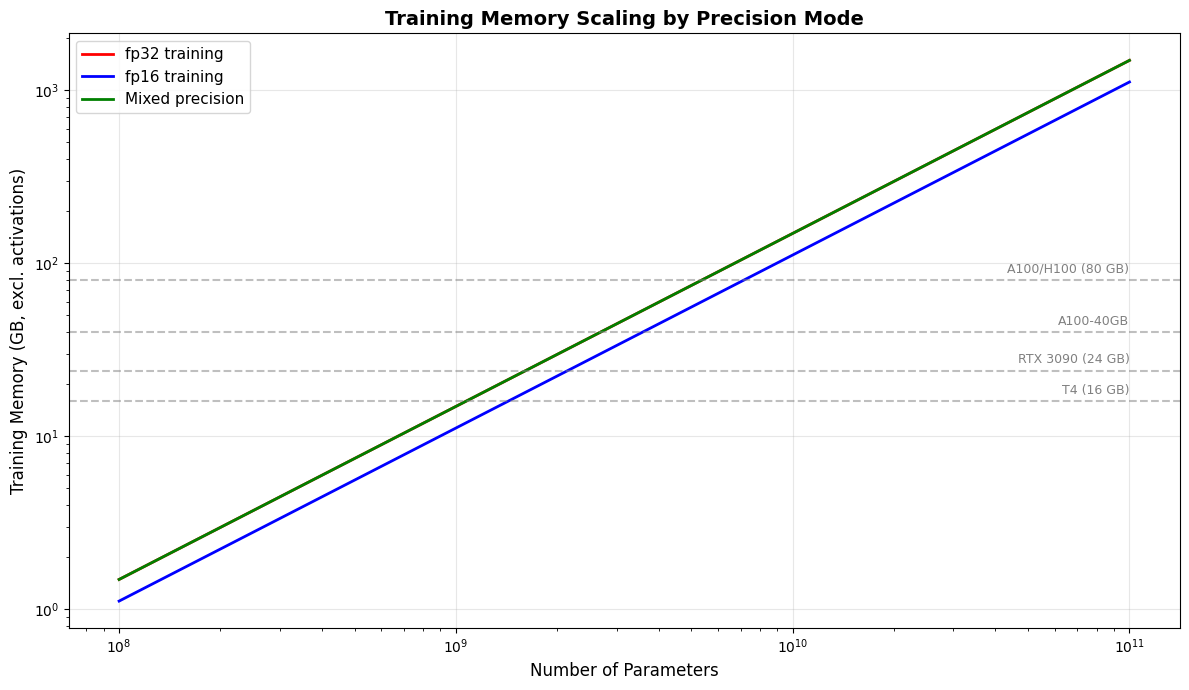

In [13]:
# TODO: Create the scaling law visualization

param_range = np.logspace(8, 11, 50)  # 100M to 100B

# TODO: Compute memory for each precision mode
fp32_mem = [training_memory_breakdown(p, 'fp32')['total'] for p in param_range]
fp16_mem = [training_memory_breakdown(p, 'fp16')['total'] for p in param_range]
mixed_mem = [training_memory_breakdown(p, 'mixed')['total'] for p in param_range]

# TODO: Create the plot
# - Use plt.loglog() for both axes in log scale
# - Plot three lines for fp32, fp16, mixed
# - Add horizontal lines for GPU sizes: 16, 24, 40, 80 GB
# - Add labels and legend

# plt.figure(figsize=(12, 7))
# ... YOUR CODE HERE ...
# plt.show()
param_range = np.logspace(8, 11, 50)  # 100M to 100B

# Compute memory for each precision mode
fp32_mem = [training_memory_breakdown(p, 'fp32')['total'] for p in param_range]
fp16_mem = [training_memory_breakdown(p, 'fp16')['total'] for p in param_range]
mixed_mem = [training_memory_breakdown(p, 'mixed')['total'] for p in param_range]

# Create the plot
plt.figure(figsize=(12, 7))
plt.loglog(param_range, fp32_mem, 'r-', linewidth=2, label='fp32 training')
plt.loglog(param_range, fp16_mem, 'b-', linewidth=2, label='fp16 training')
plt.loglog(param_range, mixed_mem, 'g-', linewidth=2, label='Mixed precision')

  # GPU memory lines
gpu_sizes = [(16, 'T4 (16 GB)'), (24, 'RTX 3090 (24 GB)'), (40, 'A100-40GB'), (80, 'A100/H100 (80 GB)')]
for mem, name in gpu_sizes:
      plt.axhline(y=mem, color='gray', linestyle='--', alpha=0.5)
      plt.text(param_range[-1], mem * 1.1, name, fontsize=9, ha='right', color='gray')

plt.xlabel('Number of Parameters', fontsize=12)
plt.ylabel('Training Memory (GB, excl. activations)', fontsize=12)
plt.title('Training Memory Scaling by Precision Mode', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Putting It All Together

Let us build a comprehensive memory report function that summarizes everything we have learned.

In [14]:
def memory_report(model_name, num_params, precision="mixed"):
    """Print a comprehensive memory report for a model."""
    mem = training_memory_breakdown(num_params, precision)

    print(f"\n{'='*60}")
    print(f"  Memory Report: {model_name}")
    print(f"  Precision: {precision}")
    print(f"  Parameters: {num_params/1e9:.1f}B" if num_params >= 1e9 else f"  Parameters: {num_params/1e6:.0f}M")
    print(f"{'='*60}")
    print(f"")
    print(f"  {'Component':<30} {'Memory':>10} {'Share':>8}")
    print(f"  {'-'*48}")
    print(f"  {'Weights':<30} {mem['weights']:>8.2f} GB {mem['weights']/mem['total']*100:>6.1f}%")
    print(f"  {'Gradients':<30} {mem['gradients']:>8.2f} GB {mem['gradients']/mem['total']*100:>6.1f}%")
    print(f"  {'Optimizer States':<30} {mem['optimizer']:>8.2f} GB {mem['optimizer']/mem['total']*100:>6.1f}%")
    print(f"  {'-'*48}")
    print(f"  {'TOTAL (excl. activations)':<30} {mem['total']:>8.2f} GB {100:>6.1f}%")
    print(f"")

    # GPU fit check
    gpus = [("T4 (16 GB)", 16), ("RTX 3090 (24 GB)", 24),
            ("A100 (40 GB)", 40), ("A100 (80 GB)", 80), ("H100 (80 GB)", 80)]
    print(f"  GPU Fit Check (excl. activations):")
    for gpu_name, gpu_mem in gpus:
        fits = "FITS" if mem['total'] <= gpu_mem else "TOO LARGE"
        symbol = "[OK]" if fits == "FITS" else "[X] "
        print(f"    {symbol} {gpu_name:<25} {fits}")
    print()

# Generate reports
memory_report("GPT-2", 124e6, "mixed")
memory_report("LLaMA-7B", 7e9, "mixed")
memory_report("LLaMA-70B", 70e9, "mixed")


  Memory Report: GPT-2
  Precision: mixed
  Parameters: 124M

  Component                          Memory    Share
  ------------------------------------------------
  Weights                            0.23 GB   12.5%
  Gradients                          0.23 GB   12.5%
  Optimizer States                   1.39 GB   75.0%
  ------------------------------------------------
  TOTAL (excl. activations)          1.85 GB  100.0%

  GPU Fit Check (excl. activations):
    [OK] T4 (16 GB)                FITS
    [OK] RTX 3090 (24 GB)          FITS
    [OK] A100 (40 GB)              FITS
    [OK] A100 (80 GB)              FITS
    [OK] H100 (80 GB)              FITS


  Memory Report: LLaMA-7B
  Precision: mixed
  Parameters: 7.0B

  Component                          Memory    Share
  ------------------------------------------------
  Weights                           13.04 GB   12.5%
  Gradients                         13.04 GB   12.5%
  Optimizer States                  78.23 GB   75.0%
  

## 7. Training and Results

Let us verify our formulas by actually training our TinyTransformer and measuring GPU memory usage.

In [15]:
# Measure actual GPU memory during training

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Create model on GPU
    model_gpu = TinyTransformer().to(device)
    optimizer_gpu = torch.optim.Adam(model_gpu.parameters(), lr=1e-4)

    # Measure memory at each stage
    mem_after_model = torch.cuda.memory_allocated() / 1e9
    print(f"After loading model: {mem_after_model:.4f} GB")

    # Forward pass
    dummy = torch.randint(0, 32000, (4, 128)).to(device)
    output = model_gpu(dummy)
    mem_after_forward = torch.cuda.memory_allocated() / 1e9
    print(f"After forward pass:  {mem_after_forward:.4f} GB (+{mem_after_forward - mem_after_model:.4f} GB activations)")

    # Backward pass
    loss = output.sum()
    loss.backward()
    mem_after_backward = torch.cuda.memory_allocated() / 1e9
    print(f"After backward pass: {mem_after_backward:.4f} GB (+{mem_after_backward - mem_after_forward:.4f} GB gradients)")

    # Optimizer step
    optimizer_gpu.step()
    mem_after_optim = torch.cuda.memory_allocated() / 1e9
    print(f"After optimizer step: {mem_after_optim:.4f} GB (+{mem_after_optim - mem_after_backward:.4f} GB opt states)")

    print(f"\nPeak memory: {torch.cuda.max_memory_allocated() / 1e9:.4f} GB")

    # Compare to theoretical
    num_p = sum(p.numel() for p in model_gpu.parameters())
    theoretical = training_memory_breakdown(num_p, "fp32")  # model is fp32 on GPU
    print(f"\nTheoretical (excl. activations): {theoretical['total']:.4f} GB")
    print(f"Measured (incl. activations): {mem_after_optim:.4f} GB")

    del model_gpu, optimizer_gpu
    torch.cuda.empty_cache()
else:
    print("GPU not available. The memory measurement above works best on Colab with a GPU runtime.")
    print("You can still study the formulas and calculations -- the theoretical analysis is the key takeaway.")

After loading model: 2.7722 GB
After forward pass:  3.2261 GB (+0.4539 GB activations)
After backward pass: 3.3667 GB (+0.1406 GB gradients)
After optimizer step: 4.4415 GB (+1.0747 GB opt states)

Peak memory: 4.9788 GB

Theoretical (excl. activations): 1.9999 GB
Measured (incl. activations): 4.4415 GB


## 8. Final Output

Let us summarize the key formulas and create a reference card.

In [16]:
print("="*60)
print("SUMMARY: GPU Memory -- Weights, Gradients, Optimizer States")
print("="*60)
print()
print("Key Formulas (per parameter):")
print("  fp32 training:  4 + 4 + 8 = 16 bytes/param")
print("  mixed training: 2 + 2 + 12 = 16 bytes/param")
print("  (Weights + Gradients + Optimizer)")
print()
print("Quick Reference:")
for name, params in models_to_check.items():
    mem = training_memory_breakdown(params, 'mixed')
    print(f"  {name}: {mem['total']:.1f} GB (excl. activations)")
print()
print("Key Insights:")
print("  1. Optimizer states dominate (75% of non-activation memory)")
print("  2. Weights alone are a poor estimate of training memory")
print("  3. Total = 16 bytes/param + activations")
print("  4. ZeRO targets optimizer states because they are the largest component")

SUMMARY: GPU Memory -- Weights, Gradients, Optimizer States

Key Formulas (per parameter):
  fp32 training:  4 + 4 + 8 = 16 bytes/param
  mixed training: 2 + 2 + 12 = 16 bytes/param
  (Weights + Gradients + Optimizer)

Quick Reference:
  GPT-2 (124M): 1.8 GB (excl. activations)
  LLaMA-7B: 104.3 GB (excl. activations)
  LLaMA-13B: 193.7 GB (excl. activations)
  LLaMA-70B: 1043.1 GB (excl. activations)

Key Insights:
  1. Optimizer states dominate (75% of non-activation memory)
  2. Weights alone are a poor estimate of training memory
  3. Total = 16 bytes/param + activations
  4. ZeRO targets optimizer states because they are the largest component


## 9. Reflection and Next Steps

**Questions to think about:**
1. Why must optimizer states be stored in fp32 even when using fp16 weights?
2. If you switch from Adam to SGD with momentum, how much memory do you save for a 7B model?
3. Why is mixed precision training *slower* than pure fp16 on the optimizer step, yet faster overall?

**What comes next:**
In the next notebook, we will tackle the fourth memory component: **activations**. We will measure activation memory empirically, understand how it scales with batch size and sequence length, and explore mixed precision training.